## Predictive Maintenance Analysis

In [1]:
# import the necessary library 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset 

In [3]:
df = pd.read_csv("Predictive_Maintenance.csv")

## Understanding the dataset 

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
# checking the null value
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
# checking the information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
# check the size of the dataset
df.shape

(10000, 14)

In [8]:
# analysis the summary statics of dataset
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Exploratory data Analysis

In [9]:
# CHECKING THE DUPLICATE ROW
df.duplicated().sum()

np.int64(0)

## UNIVARIATE ANALYSIS

<Axes: xlabel='Machine failure', ylabel='count'>

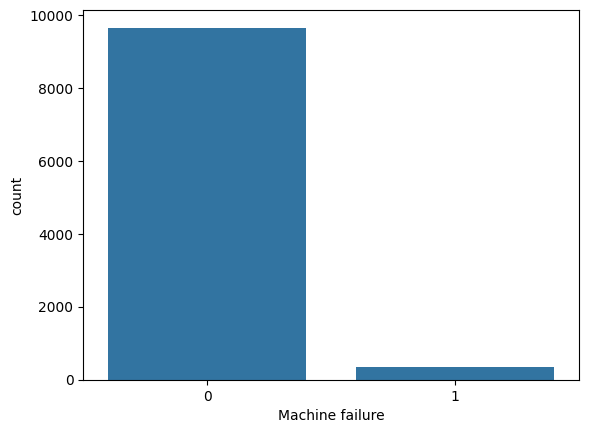

In [10]:
# Target variable distribution
sns.countplot(x = "Machine failure", data = df)

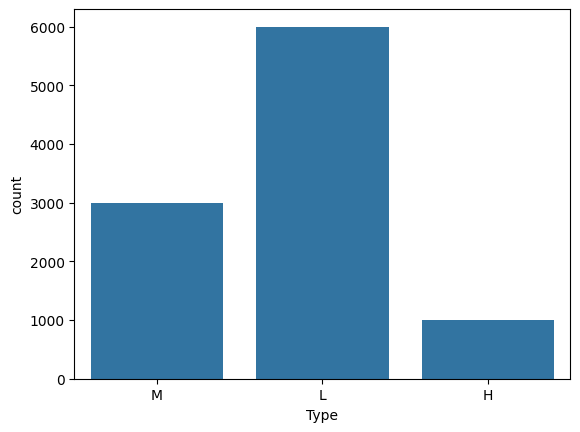

In [11]:
# Machine Type Distribution
sns.countplot(x="Type", data=df)

plt.show()

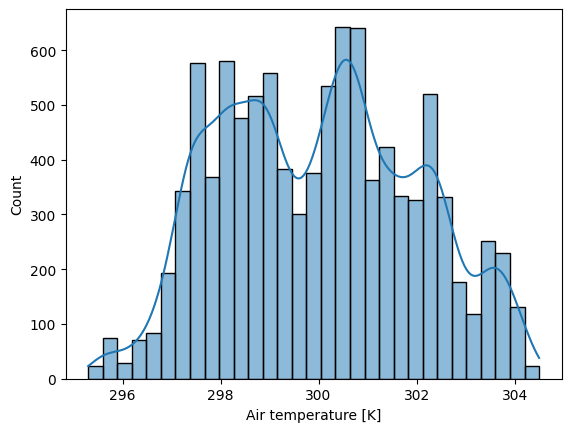

In [12]:
# checking the air temperature 
sns.histplot(df["Air temperature [K]"], kde=True)

plt.show()

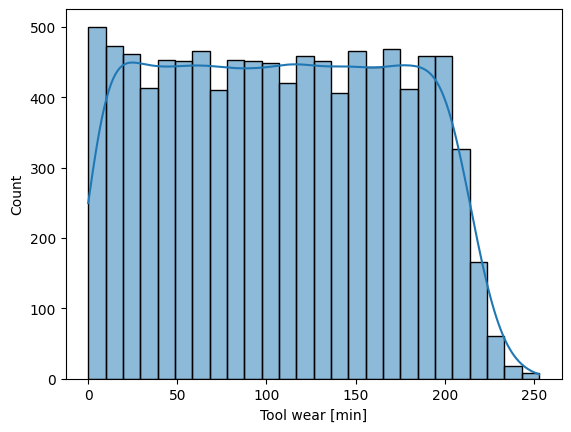

In [13]:
# checking the tool wear 
sns.histplot(df["Tool wear [min]"], kde=True)

plt.show()

## Bivariate Analysis

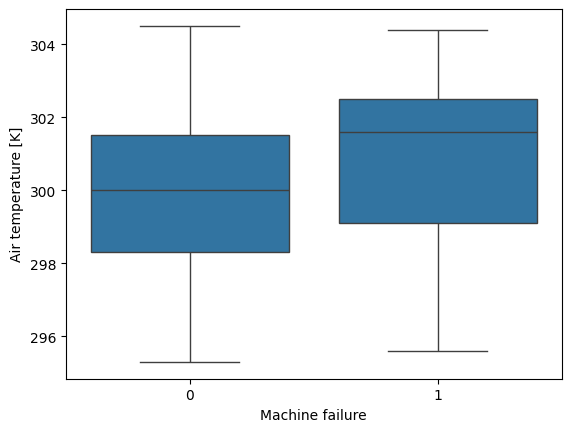

In [14]:
sns.boxplot(
x="Machine failure",
y="Air temperature [K]",
data=df
)

plt.show()

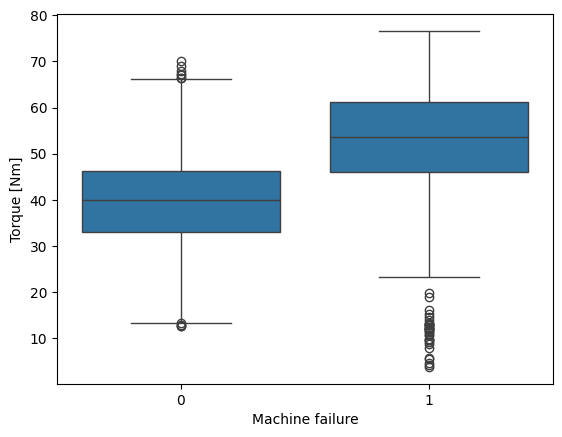

In [15]:
# Failure vs Torque
sns.boxplot(
x="Machine failure",
y="Torque [Nm]",
data=df
)

plt.show()

In [16]:
# Remove the outlier from the dataset
Q1 = df["Torque [Nm]"].quantile(0.25)
Q3 = df["Torque [Nm]"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df["Torque [Nm]"] >= lower) & (df["Torque [Nm]"] <= upper)]

In [17]:
# Using the z -score to remove the outlier 
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(df["Torque [Nm]"]))

df_clean = df[z < 3]

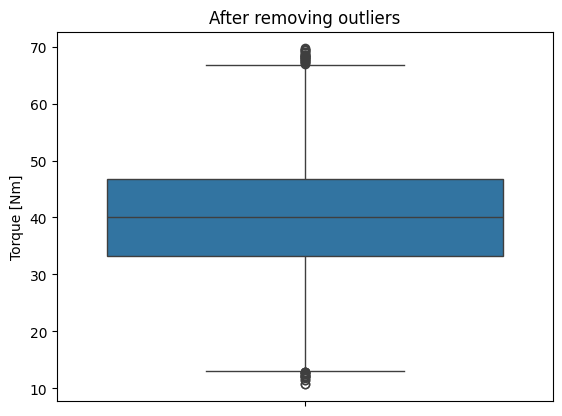

In [18]:
# Checking again the outlier in the dataset 
sns.boxplot(y=df_clean["Torque [Nm]"])
plt.title("After removing outliers")
plt.show()

In [19]:
# Again checking the outlier in the dataset
Q1 = df_clean["Torque [Nm]"].quantile(0.25)
Q3 = df_clean["Torque [Nm]"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean2 = df_clean[(df_clean["Torque [Nm]"] >= lower) & (df_clean["Torque [Nm]"] <= upper)]

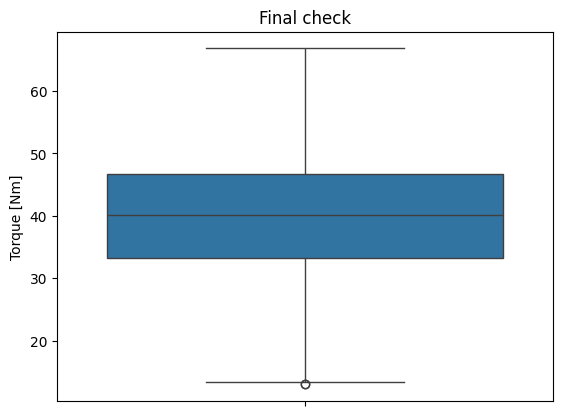

In [20]:
# ploting the bosplot to see the outlier in the model
sns.boxplot(y=df_clean2["Torque [Nm]"])
plt.title("Final check")
plt.show()

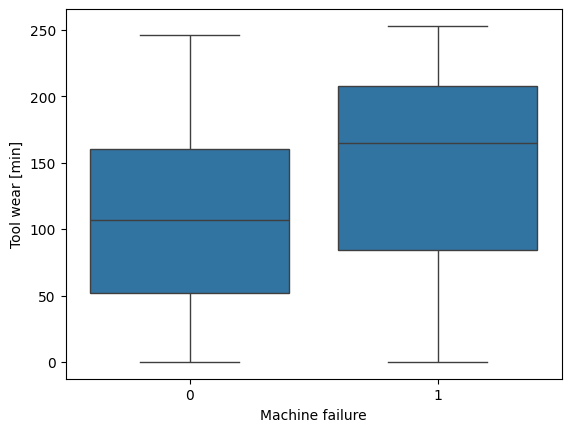

In [21]:
# Failure VS Toolwear
sns.boxplot(x = "Machine failure",
            y = "Tool wear [min]",
            data = df
           )
plt.show()

## Multivariate Analysis 

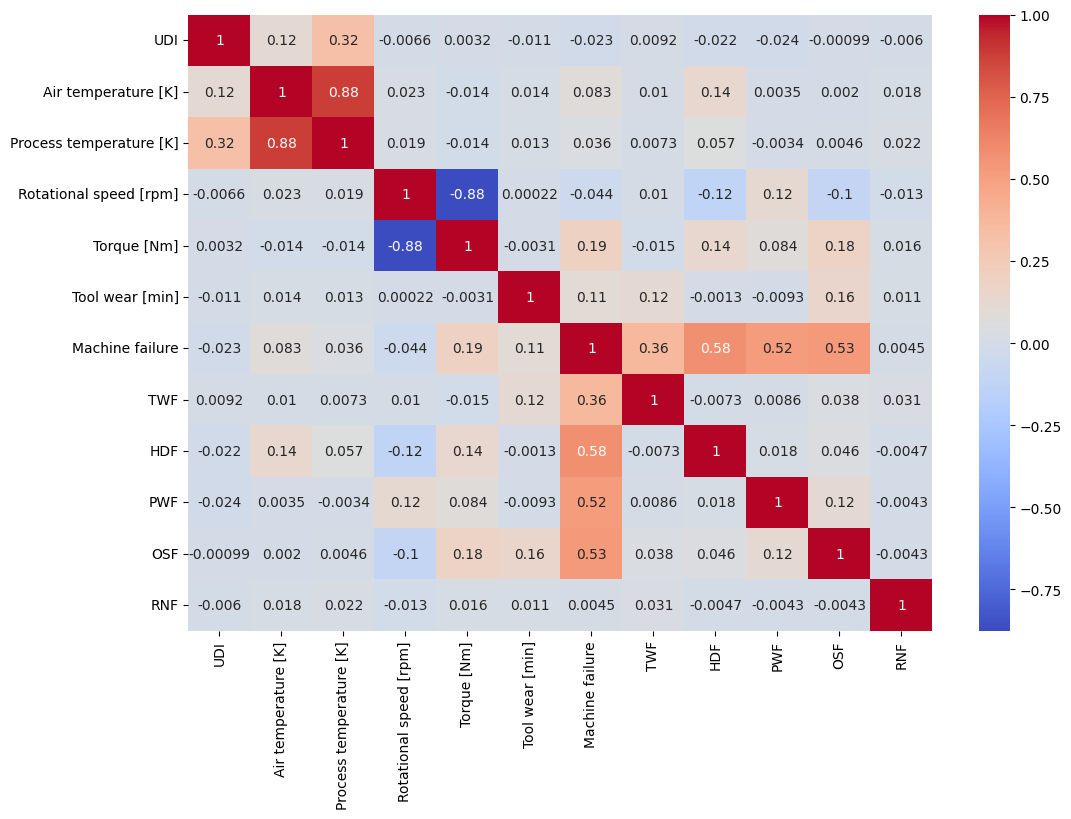

In [22]:
# Correlation Matrix
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

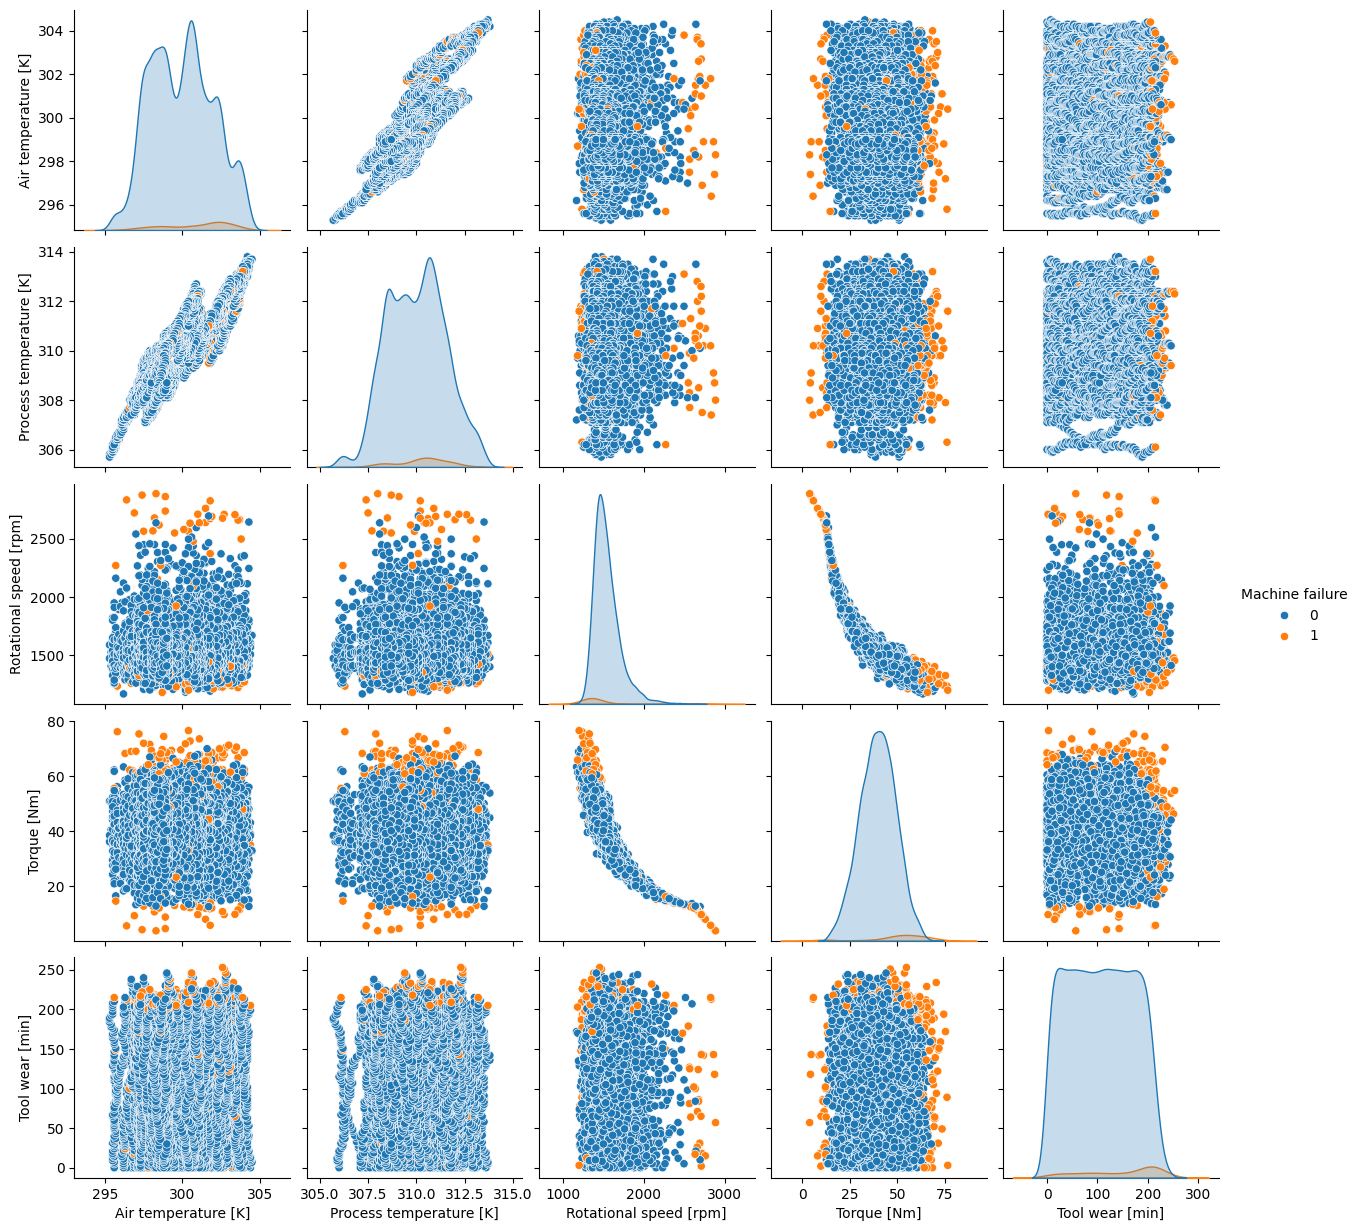

In [23]:
sns.pairplot(
df[[
'Air temperature [K]',
'Process temperature [K]',
'Rotational speed [rpm]',
'Torque [Nm]',
'Tool wear [min]',
'Machine failure'
]],
hue="Machine failure"
)

plt.show()

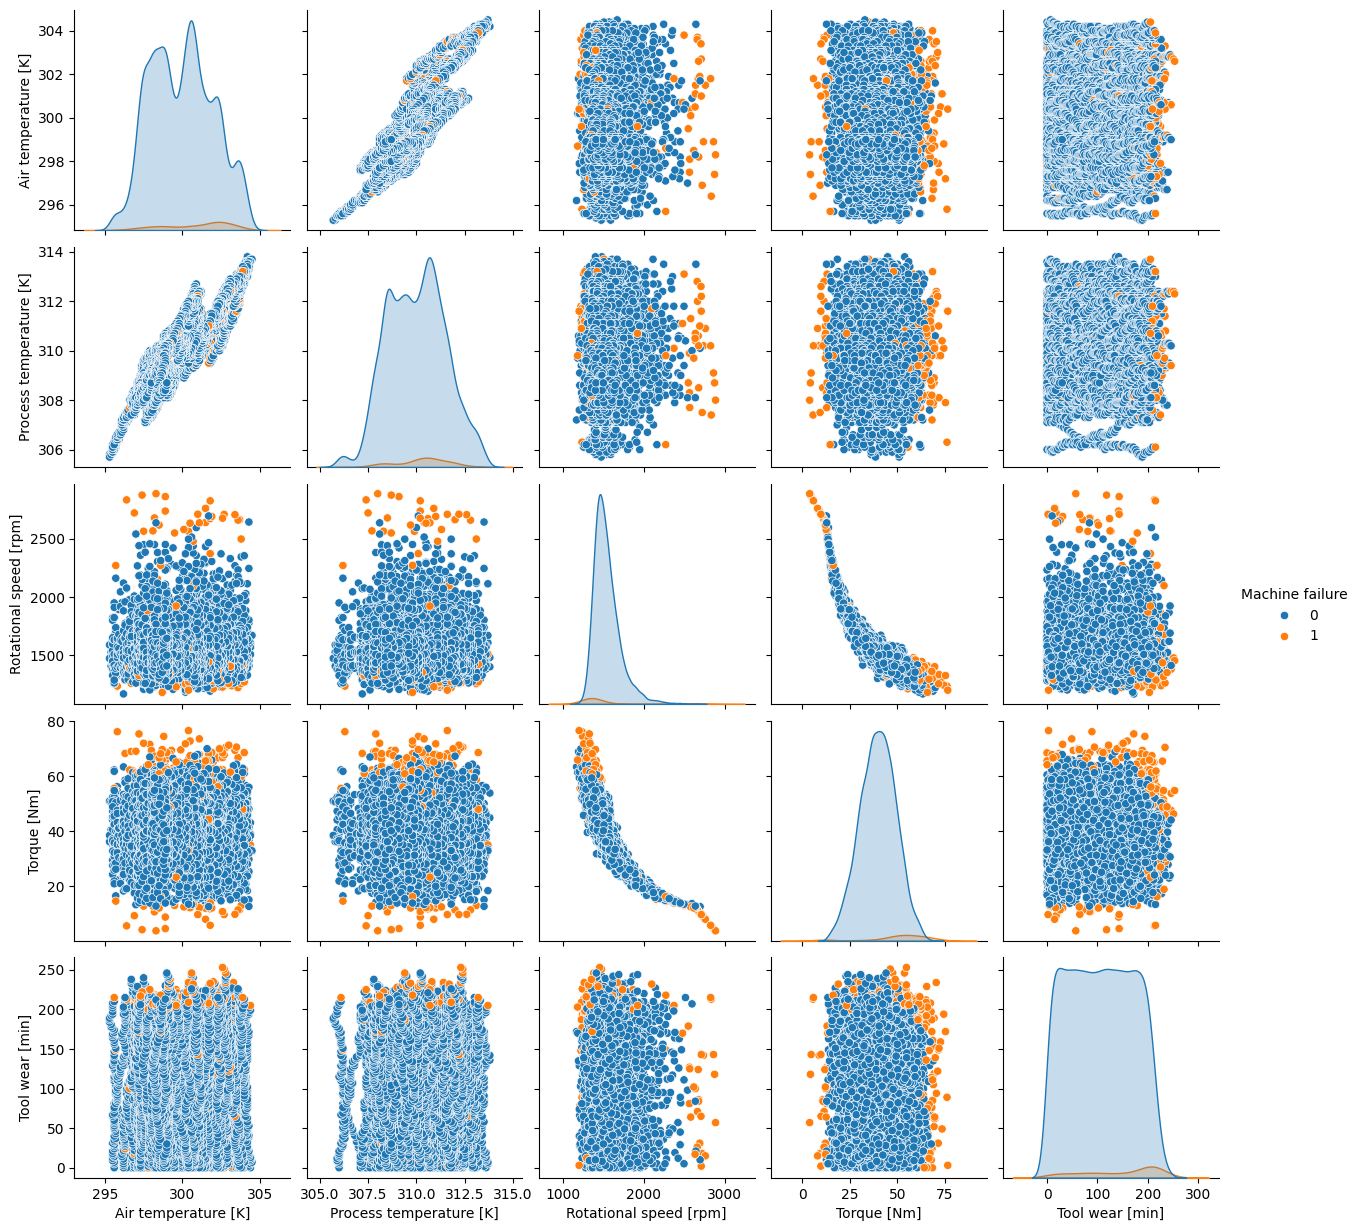

In [24]:
sns.pairplot(
df[[
'Air temperature [K]',
'Process temperature [K]',
'Rotational speed [rpm]',
'Torque [Nm]',
'Tool wear [min]',
'Machine failure'
]],
hue="Machine failure"
)

plt.show()

## Advanced EDA

In [25]:
# Failure Reason Distribution
failure_columns = [
"TWF",
"HDF",
"PWF",
"OSF",
"RNF"
]

df[failure_columns].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

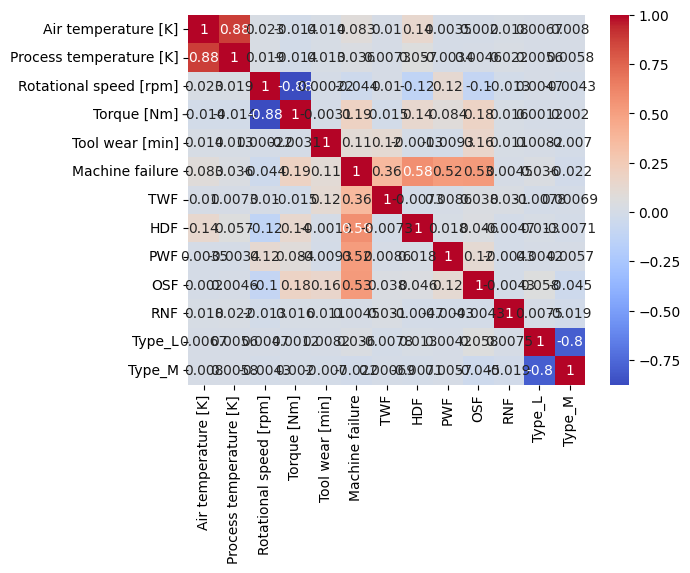

In [26]:
# remove unnecessary columns
df = df.drop(["UDI","Product ID"], axis=1)

# convert categorical to numeric
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

# correlation
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

In [27]:
df.groupby("Machine failure").mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
Machine failure,,,,,,,,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717,0.000000,0.000000,0.000000,0.000000,0.001863,0.596729,0.301625
1,300.886431,310.290265,1496.486726,50.168142,143.781711,0.135693,0.339233,0.280236,0.289086,0.002950,0.693215,0.244838


## Feature Engineering

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = [
'Air temperature [K]',
'Process temperature [K]',
'Rotational speed [rpm]',
'Torque [Nm]',
'Tool wear [min]'
]

df[features] = scaler.fit_transform(df[features])

## Create a new feature 

In [29]:
# Temperature difference feature

In [30]:
df["temp_diff"] = (
df["Process temperature [K]"]
-
df["Air temperature [K]"]
)

In [31]:
# Power feature
df["power"] = (
df["Torque [Nm]"]
*
df["Rotational speed [rpm]"]
)

In [32]:
# Wear rate feature
df["wear_rate"] = (
df["Tool wear [min]"]
/
df["Rotational speed [rpm]"]
)

## Handle the imbalanced dataset

In [33]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [34]:
# Using the SMOTE techinque
from imblearn.over_sampling import SMOTE

X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

smote = SMOTE()

X_resampled, y_resampled = smote.fit_resample(X,y)

## Feature Important Check

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X,y)

importance = model.feature_importances_

feature_imp = pd.Series(
importance,
index=X.columns
)

feature_imp.sort_values(ascending=False)

HDF                        0.243471
OSF                        0.202750
PWF                        0.156689
TWF                        0.108995
Torque [Nm]                0.079846
Rotational speed [rpm]     0.056430
power                      0.038490
temp_diff                  0.031985
Tool wear [min]            0.025941
wear_rate                  0.019703
Air temperature [K]        0.017753
Process temperature [K]    0.013444
Type_L                     0.002983
Type_M                     0.001208
RNF                        0.000312
dtype: float64

In [36]:
X = df[
[
'Air temperature [K]',
'Process temperature [K]',
'Rotational speed [rpm]',
'Torque [Nm]',
'Tool wear [min]',
'temp_diff',
'power',
'wear_rate'
]
]

y = df["Machine failure"]

## Model Training 

In [37]:
# Define the target variable
X = df.drop("Machine failure", axis=1)

y = df["Machine failure"]

## Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

## Model 1 :- Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction

In [40]:
y_pred = rf_model.predict(X_test)

## Model Evaluation 

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [42]:
print(model.score(X_train, y_train))

1.0


## Confustion Matrix

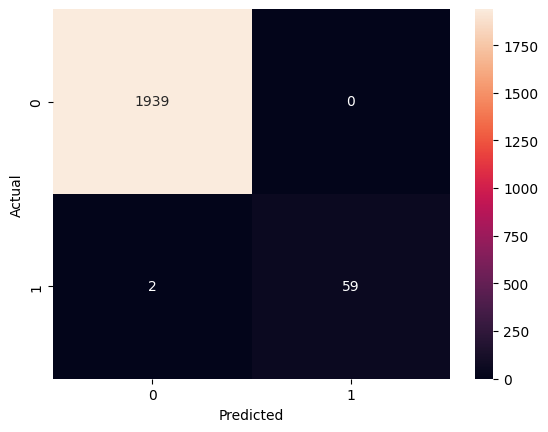

In [43]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance 

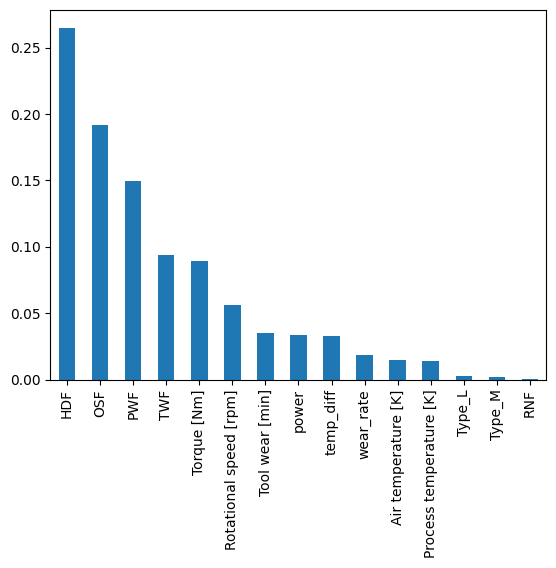

In [44]:
importance = rf_model.feature_importances_

feature_imp = pd.Series(
importance,
index=X.columns
)

feature_imp.sort_values(
ascending=False
).plot(
kind='bar'
)

plt.show()

## Model 2 :- Xgboost 

In [45]:
!pip install xgboost

In [46]:
X_train.dtypes

Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]     float64
Torque [Nm]                float64
Tool wear [min]            float64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
Type_L                        bool
Type_M                        bool
temp_diff                  float64
power                      float64
wear_rate                  float64
dtype: object

In [47]:
import pandas as pd

X = pd.get_dummies(X, drop_first=True)

In [48]:
# remove special characters from column names
X_train.columns = X_train.columns.str.replace("[", "", regex=False).str.replace("]", "", regex=False)
X_test.columns = X_test.columns.str.replace("[", "", regex=False).str.replace("]", "", regex=False)

# train model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

In [49]:
# Prediction
y_pred_xgb = xgb_model.predict(X_test)

## Evaluation

In [50]:
print(
classification_report(
y_test,
y_pred_xgb
)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



## Applying the Deep Learning

In [51]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Build NeuraL Network

In [52]:
model = Sequential()

model.add(Dense(
64,
activation='relu',
input_shape=(X_train.shape[1],)
))

model.add(Dense(
32,
activation='relu'
))

model.add(Dense(
1,
activation='sigmoid'
))

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [53]:
model.compile(

optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy']
)

## Train Model

In [54]:
history = model.fit(

X_train,
y_train,

epochs=20,

batch_size=32,

validation_split=0.2
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9072 - loss: 0.2813 - val_accuracy: 0.9594 - val_loss: 0.1337
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9781 - loss: 0.0793 - val_accuracy: 0.9781 - val_loss: 0.0808
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9914 - loss: 0.0424 - val_accuracy: 0.9912 - val_loss: 0.0426
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9952 - loss: 0.0221 - val_accuracy: 0.9931 - val_loss: 0.0298
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9973 - loss: 0.0191 - val_accuracy: 0.9956 - val_loss: 0.0227
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9987 - loss: 0.0108 - val_accuracy: 0.9969 - val_loss: 0.0182
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9984 - loss: 0.0115 - val_accuracy: 0.9956 - val_loss: 0.0232
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9989 - loss: 0.0196 - val_accuracy: 0.

## Evaluate Model

In [55]:
loss, accuracy = model.evaluate(

X_test,
y_test
)

print("Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9990 - loss: 0.0082
Accuracy: 0.9990000128746033


## Prediction

In [56]:
pred = model.predict(X_test)

pred = (pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


## Save Trained Model

In [57]:
import joblib

joblib.dump(rf_model,"model.pkl")

['model.pkl']